# Cursos de Machine Learning en el Sector Bancario
## Modulo 11. `Forecasting de visitas a sucursales bancarias con Deep Learning`
                        Elaborado por: Naren Castellon

## `Dataset`

Dataset sintético para pronóstico de visitas a sucursales bancarias


- unique_id: ID de sucursal ('Branch_1' a 'Branch_10')
- ds: Fecha diaria (timestamp)
- y: Visitas diarias (target principal, con tendencia, estacionalidad semanal/anual y ruido)
- temperature: Temperatura diaria (exógena, más visitas en clima moderado)
- holiday_flag: Indicador de feriado (0/1, menos visitas)
- day_of_week: Día de la semana (0-6, más visitas laborables)
- month: Mes del año (1-12, estacionalidad anual)
- is_weekend: Indicador fin de semana (0/1)
- marketing_campaign: Campaña activa (0/1, boost visitas)
- economic_indicator: Indicador económico sintético (e.g., confianza consumidor)
- interest_rate: Tasa de interés (exógena, afecta visitas por consultas financieras)
- local_event: Evento local (0/1, boost visitas)

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0



In [ ]:
import torch
device = torch.device("cpu")

In [1]:
import pandas as pd  # Para manipulación de datos, creación de DataFrames y manejo de series temporales multivariadas
import numpy as np   # Para generación de datos sintéticos numéricos, operaciones matemáticas y ruido
from datetime import datetime, timedelta  # Para generar fechas diarias secuenciales
import matplotlib.pyplot as plt  # Para visualizaciones básicas como gráficos de series temporales y forecasts
import seaborn as sns  # Para gráficos avanzados en EDA, como heatmaps o distribuciones
# Utilsforecast
# ==============================================================================
from utilsforecast.plotting import plot_series

from neuralforecast import NeuralForecast  # Librería principal para forecasting con deep learning (modelos como NHITS, NBEATS)
from neuralforecast.models import NHITS, NBEATS, xLSTM  # Modelos específicos: NHITS para tendencias/estacionalidad compleja, NBEATS para descomposición
from neuralforecast.losses.pytorch import MAE  # Métrica de loss (Mean Absolute Error) para entrenamiento
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Métricas para evaluación del forecast (MAE, RMSE)
from neuralforecast.losses.pytorch import GMM, MQLoss, DistributionLoss
import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings menores para salida limpia

/opt/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-16 20:24:28,090	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-16 20:24:28,215	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
visits_df = pd.read_csv('./bank_branch_visits_data.csv')
visits_df

,unique_id,ds,y,temperature,holiday_flag,day_of_week,month,is_weekend,marketing_campaign,economic_indicator,interest_rate,local_event
0,Branch_1,2015-01-01,95,9.8,0,3,1,0,0,60.02,2.04,0
1,Branch_1,2015-01-02,156,20.4,0,4,1,0,0,48.02,2.99,0
2,Branch_1,2015-01-03,116,20.8,0,5,1,1,0,55.70,3.18,0
3,Branch_1,2015-01-04,125,18.1,0,6,1,1,0,61.21,4.79,0
4,Branch_1,2015-01-05,145,23.1,0,0,1,0,0,62.97,3.79,0
...,...,...,...,...,...,...,...,...,...,...,...,...
40175,Branch_10,2025-12-27,389,17.3,0,5,12,1,0,66.77,5.23,0
40176,Branch_10,2025-12-28,385,9.8,0,6,12,1,0,86.00,5.98,0
40177,Branch_10,2025-12-29,388,24.9,0,0,12,0,0,74.78,3.29,0
40178,Branch_10,2025-12-30,460,16.5,0,1,12,0,0,88.59,2.13,0


In [ ]:
visits_df.info()

In [3]:
# Convertir ds a datetime
visits_df['ds'] = pd.to_datetime(visits_df['ds'])

In [ ]:
visits_df.dtypes

In [ ]:
# Resumen estadístico
print("\nEstadísticas descriptivas:")
print(visits_df.describe())

In [ ]:
# Visualizar visitas promedio por sucursal
avg_visits = visits_df.groupby('unique_id')['y'].mean()
avg_visits.plot(kind='bar', figsize=(18, 6))
plt.title('Visitas Promedio Diarias por Sucursal')
plt.ylabel('Visitas')
plt.show()

In [ ]:
visits_df.head()

In [ ]:
# Correlación entre variables numéricas
numeric_cols = ['y', 'temperature', 'economic_indicator', 'interest_rate']
corr_matrix = visits_df[numeric_cols].corr()
plt.figure(figsize=(18, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
# Estacionalidad semanal en visitas (ejemplo sucursal 1)
branch1 = visits_df[visits_df['unique_id'] == 'Branch_1']
plt.figure(figsize=(18, 6))
sns.lineplot(x='ds', y='y', data=branch1.iloc[:365])  # Primer año para claridad
plt.title('Visitas Diarias - Sucursal 1 (Primer Año)')
plt.xlabel('Fecha')
plt.ylabel('Visitas')
plt.show()

In [ ]:
plot_series(visits_df, max_insample_length= 365)

In [ ]:
visits_df.head()

In [4]:
# Dividir train/test (últimos 90 días como test por sucursal)
train_df = visits_df.groupby('unique_id').apply(lambda x: x.iloc[:-90]).reset_index(drop=True)
test_df = visits_df.groupby('unique_id').apply(lambda x: x.iloc[-90:]).reset_index(drop=True)

train_df.shape, test_df.shape

((39280, 12), (900, 12))

In [5]:
train_df.columns

Index(['unique_id', 'ds', 'y', 'temperature', 'holiday_flag', 'day_of_week',
       'month', 'is_weekend', 'marketing_campaign', 'economic_indicator',
       'interest_rate', 'local_event'],
      dtype='object')

In [6]:
models  = xLSTM(
    h = 250,
    input_size= 365,
    loss =  MQLoss(level = [80, 95]),
    valid_loss =  MQLoss(level = [80, 95]),
    max_steps= 300,
    scaler_type=  'robust', # 'robust', 'standard',  
    learning_rate = 1e-3,
    futr_exog_list = ['temperature', 'holiday_flag', 'day_of_week', 'month', 'is_weekend', 'marketing_campaign', 'economic_indicator', 'interest_rate', 'local_event'],
    hist_exog_list = ['temperature', 'holiday_flag', 'day_of_week', 'month', 'is_weekend', 'marketing_campaign', 'economic_indicator', 'interest_rate', 'local_event'],
    #valid_batch_size = 8,
)

Seed set to 1


In [7]:
nf = NeuralForecast(models = [models], freq = 'D')

In [8]:
# Entrenar modelos
print("Entrenando modelos con NeuralForecast...")
nf.fit(df = train_df, )

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                | Type            | Params | Mode 
----------------------------------------------------------------
0 | loss                | MQLoss          | 5      | train
1 | valid_loss          | MQLoss          | 5      | train
2 | padder_train        | ConstantPad1d   | 0      | train
3 | scaler              | TemporalNorm    | 0      | train
4 | feature_projection  | Linear          | 2.6 K  | train
5 | hist_encoder        | xLSTMBlockStack | 221 K  | train
6 | mlp_decoder         | MLP             | 18.3 K | train
7 | temporal_projection | Linear          | 91.5 K | train
----------------------------------------------------------------
334 K     Trainable params
10        Non-trainable params
334 K     Total params
1.337     Total estimated model params size (MB)
49        Modules in train mode
0         Modules in eval mode


Entrenando modelos con NeuralForecast...
Epoch 299: 100%|██████████| 1/1 [00:01<00:00,  0.76it/s, v_num=21, train_loss_step=0.433, train_loss_epoch=0.433]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:01<00:00,  0.76it/s, v_num=21, train_loss_step=0.433, train_loss_epoch=0.433]


In [26]:
futr_df = pd.DataFrame()
for uid in train_df['unique_id'].unique():
    last_row = train_df[train_df['unique_id'] == uid].iloc[-1]
    futr_dates = pd.date_range(start=last_row['ds'] + timedelta(days=1), periods=250, freq='D')
    futr_rows = pd.DataFrame({
        'unique_id': [uid] * 250,
        'ds': futr_dates,
        'temperature': 20 + 15 * np.sin(2 * np.pi * (futr_dates.dayofyear / 365)) + np.random.normal(0, 5, 250),
        'holiday_flag': np.random.choice([0, 1], 250, p=[0.9, 0.1]),
        'day_of_week': futr_dates.weekday,
        'month': futr_dates.month,
        'is_weekend': (futr_dates.weekday >= 5).astype(int),
        'marketing_campaign': np.random.choice([0, 1], 250, p=[0.8, 0.2]),
        'economic_indicator': np.random.normal(60, 10, 250),
        'interest_rate': np.random.uniform(3.0, 5.0, 250),
        'local_event': np.random.choice([0, 1], 250, p=[0.95, 0.05])
    })
    futr_df = pd.concat([futr_df, futr_rows])

In [27]:
futr_df.to_csv("visitas_futuras.csv", index= False)

In [31]:
futr_df = pd.read_csv("./visitas_futuras.csv")
futr_df["ds"] = pd.to_datetime(futr_df["ds"])


In [32]:
futr_df.dtypes

unique_id                     object
ds                    datetime64[ns]
temperature                  float64
holiday_flag                   int64
day_of_week                    int64
month                          int64
is_weekend                     int64
marketing_campaign             int64
economic_indicator           float64
interest_rate                float64
local_event                    int64
dtype: object

In [33]:
# Pronosticar
forecasts = nf.predict(futr_df = futr_df, )
forecasts

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  0.72it/s]


,unique_id,ds,xLSTM-median,xLSTM-lo-95,xLSTM-lo-80,xLSTM-hi-80,xLSTM-hi-95
0,Branch_1,2025-10-03,145.758545,107.991531,116.887619,179.289871,240.095535
1,Branch_1,2025-10-04,194.778137,153.333282,170.443085,225.240158,235.283966
2,Branch_1,2025-10-05,179.135391,134.147278,154.068268,210.893372,220.110703
3,Branch_1,2025-10-06,222.033173,166.431488,185.797623,260.100555,274.626251
4,Branch_1,2025-10-07,199.791718,141.692108,160.314270,237.718063,248.866760
...,...,...,...,...,...,...,...
2495,Branch_9,2026-06-05,565.369019,500.495789,522.593506,605.328369,626.849182
2496,Branch_9,2026-06-06,407.566895,360.349121,378.412628,449.718475,471.455811
2497,Branch_9,2026-06-07,372.682800,331.358337,338.364563,415.123840,431.707764
2498,Branch_9,2026-06-08,505.574646,438.150330,456.545654,552.422424,581.657410


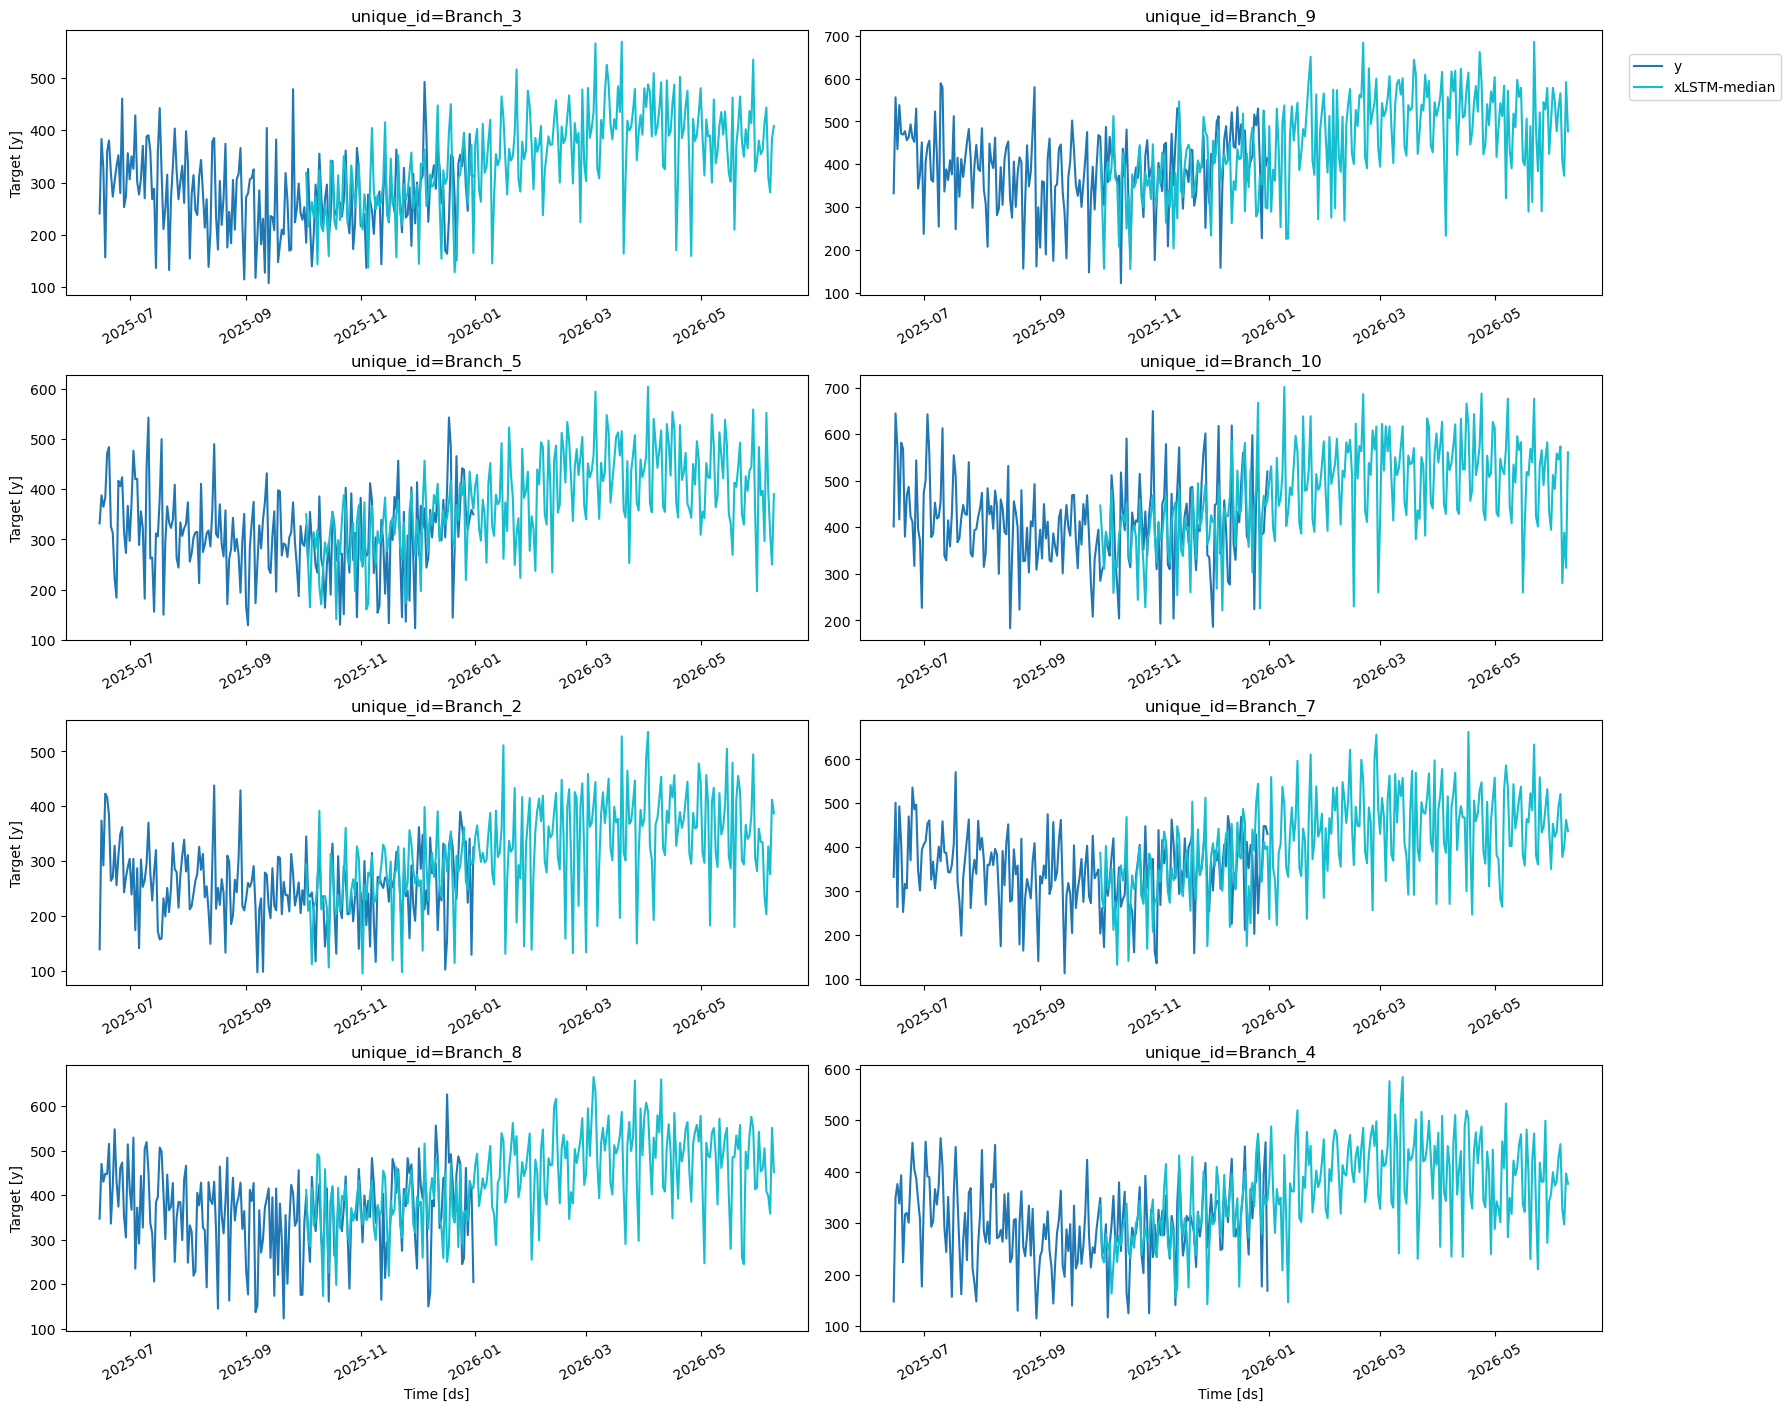

In [11]:
plot_series(visits_df, forecasts, max_insample_length= 200)

In [12]:
test_df = test_df.merge(forecasts[['unique_id', 'ds', 'xLSTM-median']], on=['unique_id', 'ds'], how='left')
test_df

,unique_id,ds,y,temperature,holiday_flag,day_of_week,month,is_weekend,marketing_campaign,economic_indicator,interest_rate,local_event,xLSTM-median
0,Branch_1,2025-10-03,216,4.2,0,4,10,0,1,68.89,4.08,0,326.180237
1,Branch_1,2025-10-04,198,2.7,0,5,10,1,0,77.31,5.21,0,194.968964
2,Branch_1,2025-10-05,74,6.7,1,6,10,1,0,60.61,4.90,0,179.167023
3,Branch_1,2025-10-06,114,10.6,1,0,10,0,0,76.11,2.44,1,222.744186
4,Branch_1,2025-10-07,178,5.3,0,1,10,0,0,83.76,4.61,0,199.440109
...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,Branch_9,2025-12-27,397,16.6,0,5,12,1,0,84.80,4.24,0,373.675476
896,Branch_9,2025-12-28,227,12.7,1,6,12,1,1,55.25,3.51,0,353.160736
897,Branch_9,2025-12-29,524,22.5,0,0,12,0,1,70.56,5.92,0,525.387390
898,Branch_9,2025-12-30,395,19.5,0,1,12,0,0,55.00,4.19,0,298.890808


In [13]:
# Métricas (usando NHITS como principal)
mae = mean_absolute_error(test_df['y'], test_df['xLSTM-median'])
rmse = np.sqrt(mean_squared_error(test_df['y'], test_df['xLSTM-median']))
print(f"\nMétricas Globales (NHITS): MAE = {mae:.2f}, RMSE = {rmse:.2f}")


Métricas Globales (NHITS): MAE = 61.64, RMSE = 85.97


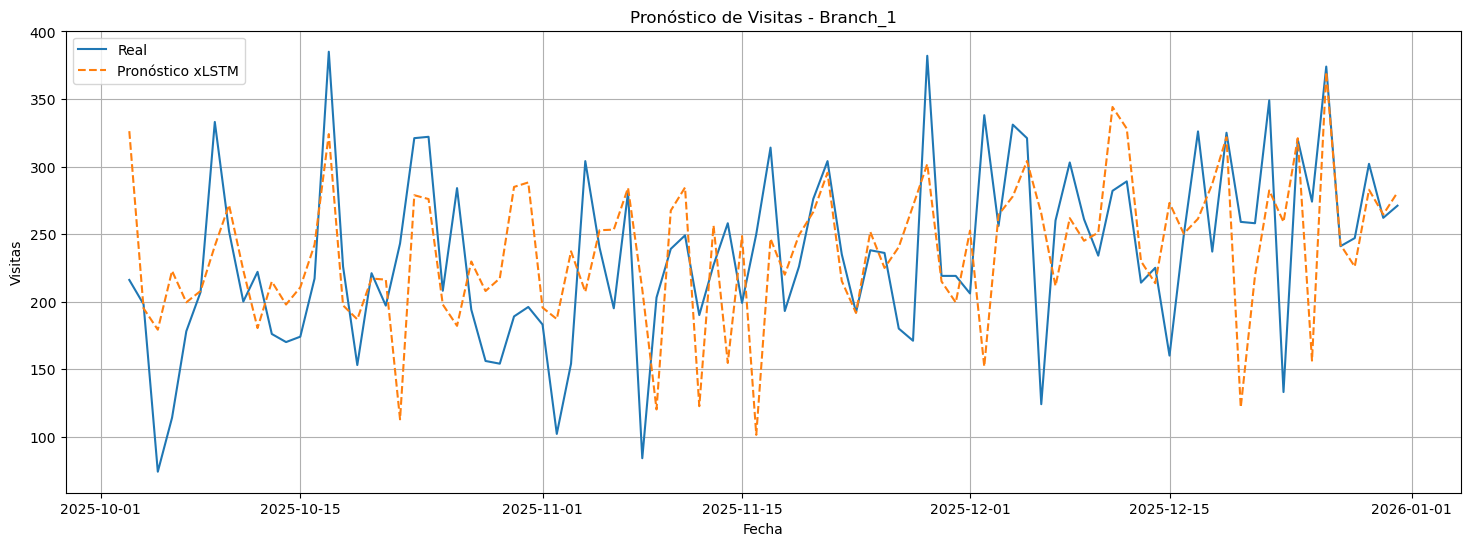

In [14]:
# Visualizar para sucursal ejemplo
example_branch = 'Branch_1'
branch_test = test_df[test_df['unique_id'] == example_branch]
plt.figure(figsize=(18, 6))
plt.plot(branch_test['ds'], branch_test['y'], label='Real')
plt.plot(branch_test['ds'], branch_test['xLSTM-median'], label='Pronóstico xLSTM', linestyle='--')
plt.title(f'Pronóstico de Visitas - {example_branch}')
plt.xlabel('Fecha')
plt.ylabel('Visitas')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Ejemplo: Personal requerido = visitas / 50 (asumiendo 50 visitas por empleado/día)
forecasts['required_staff'] = (forecasts['xLSTM-median'] / 50).round().astype(int)
staff_summary = forecasts.groupby('unique_id')['required_staff'].mean().reset_index(name='Personal Promedio Requerido (90 días)')
print("\nPersonal Promedio Requerido por Sucursal (90 días):")
print(staff_summary)


Personal Promedio Requerido por Sucursal (90 días):
   unique_id  Personal Promedio Requerido (90 días)
0   Branch_1                                  5.868
1  Branch_10                                  9.464
2   Branch_2                                  6.384
3   Branch_3                                  6.952
4   Branch_4                                  7.252
5   Branch_5                                  7.520
6   Branch_6                                  7.928
7   Branch_7                                  8.244
8   Branch_8                                  8.788
9   Branch_9                                  8.992
